# Analyse Queueing Behaviour
In this notebook we want to analyse and simulate the queueing behaviour of the Experimental Framework. We therefore analyse response time behaviour and conduct simulations using queueing theory.

In [31]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
import numpy as np
import random
# fix random seed for reproducibility
random.seed(42)
np.random.seed(42)

## 1) Load Result Dataframe
This section loads the raw results from the file systems `../results/baseline_experiments` folder and extracts the metadata from the file names. The raw results are stored in a dictionary of dataframes, where the key is the subfolder name and filename stem (e.g. "zenbook/boolq_raw_experiment_Llama-3-2-1B-Instruct-ONNX_always_device_once-per-sec_2025-12-03T20-58-00") and the value is the corresponding dataframe. The metadata extracted from the file name is stored in a separate dictionary, where the key is the same as in the raw_dfs and the value is a dictionary containing the device, dataset, model, execution mode and frequency.

In [33]:
from utils import *
import pandas as pd
from pathlib import Path

results_dir = Path('../results/baseline_experiments') # Define root results directory

raw_files = sorted(results_dir.glob('**/*raw*.csv')) # Find all files containing "raw" and ending with .csv in all subdirectories

# Load all raw experiment files into a dictionary of dataframes
raw_dfs = {}
raw_meta = {}  # a dataframe to store the metadata of the experiment extracted from the file name

for file_path in raw_files:
    try:
        df = pd.read_csv(file_path)
        df.columns = df.columns.str.strip() # Strip whitespace from column names

        # Create key: subfolder_name/filename_stem
        relative_path = file_path.relative_to(results_dir)
        key = str(relative_path.parent / relative_path.stem)
        raw_meta[key] = parse_experiment_string(key)
        raw_dfs[key] = df

        print(f"{relative_path} -> shape {df.shape}")
    except Exception as e:
        print(f"[!] Error loading {file_path.name}: {e}")

print(f"\nSUCCESS: Loaded {len(raw_dfs)} raw dataframes")

cloud/ag-news_raw_experiment_meta-llama-llama-3-2-1b-instruct_always_cloud_once-per-sec_2026-01-31T18-36-02.csv -> shape (500, 22)
cloud/ag-news_raw_experiment_openai-gpt-4-1-mini_always_cloud_once-per-sec_2026-02-01T12-19-04.csv -> shape (500, 22)
cloud/boolq_raw_experiment_meta-llama-llama-3-2-1b-instruct_always_cloud_once-per-sec_2026-02-04T09-33-25.csv -> shape (500, 22)
cloud/boolq_raw_experiment_openai-gpt-4-1-mini_always_cloud_once-per-sec_2026-01-31T19-51-47.csv -> shape (500, 22)
cloud/lorem-ipsum_raw_experiment_meta-llama-llama-3-2_always_cloud_once-per-sec.csv -> shape (201, 22)
cloud/lorem-ipsum_raw_experiment_openai-gpt-4-1-mini_always_cloud_once-per-sec.csv -> shape (202, 22)
cloud/spam_raw_experiment_meta-llama-llama-3-2-1b-instruct_always_cloud_once-per-sec_2026-01-31T17-54-44.csv -> shape (500, 22)
cloud/spam_raw_experiment_openai-gpt-4-1-mini_always_cloud_once-per-sec_2026-02-01T08-09-41.csv -> shape (500, 22)
desktop/ag-news_raw_experiment_Llama-3-2-1B-Instruct-ONNX_

## 2) Analysing Response Time Behaviour

In [34]:
from utils import *

df_cloud_ex = raw_dfs['desktop-cloud/boolq_raw_experiment_meta-llama-llama-3-2-1b-instruct_always_cloud_once-per-sec_2026-02-26T11-11-24'].copy()
df_device_ex = raw_dfs['desktop/boolq_raw_experiment_Llama-3-2-1B-Instruct-ONNX_always_device_once-per-sec_2026-02-03T16-18-29'].copy()

name_cloud = "Llama-3-2-1B-Instruct (Open Router)"
name_device = "Llama-3-2-1B-Instruct-ONNX (Desktop PC)"
name_dataset = "BoolQ"

df_device_ex['inference_time_ms'] = (df_device_ex['inference_time_ms'])
df_cloud_ex['inference_time_ms'] = (df_cloud_ex['inference_time_ms'])


We now extract basic per-server metrics from the experiment data.

In [35]:
from utils import *
extract_basic_metrics(df_device_ex, name_device)
extract_basic_metrics(df_cloud_ex, name_cloud)

--- Metrics for Llama-3-2-1B-Instruct-ONNX (Desktop PC) ---
  Count:                   500
  Duration:                501.35 s
  Arrival Rate (λ):        0.9973 req/s
  Mean Service Demand (S): 0.1946 s
  Mean Response Time (R):  0.2035 s
  Response Time P95:       0.3720 s
  Utilization (ρ = λ*S):   19.41%
------------------------------
--- Metrics for Llama-3-2-1B-Instruct (Open Router) ---
  Count:                   500
  Duration:                500.98 s
  Arrival Rate (λ):        0.9981 req/s
  Mean Service Demand (S): 0.1428 s
  Mean Response Time (R):  0.1527 s
  Response Time P95:       0.2091 s
  Utilization (ρ = λ*S):   14.25%
------------------------------


{'lambda': 0.9980537950995558,
 'mean_service_time': 0.142758,
 'mean_response_time': 0.15265199999999998,
 'p95_response_time': 0.2090999999999999,
 'utilization': 0.1424801636808224}

For our analysis, we model our cloud and on-device systems as **G/G/1** queues (General Arrival, General Service).

Since there is no exact closed-form solution for the mean waiting time in a G/G/1 queue, we use **Kingman's Approximation** (see lecture/literature). The expected waiting time $E[T_Q]$ is approximated as:

$$
E[T_Q] \approx \frac{\rho}{1-\rho} \cdot \frac{c_a^2 + c_s^2}{2} \cdot E[S]
$$

Where:
- $\rho = \lambda E[S]$ is the utilization.
- $E[S]$ is the mean service time.
- $c_a$ is the coefficient of variation of inter-arrival times ($c_a = \sigma_a / \mu_a$).
- $c_s$ is the coefficient of variation of service times ($c_s = \sigma_s / \mu_s$).

This formula generalizes the queueing behavior:
1.  **For our Experiment (G/G/1):** Since arrivals are deterministic, $c_a \approx 0$. The waiting time is driven purely by the service variability ($c_s^2$).
2.  **For M/G/1 (Theoretical):** If we assume random Poisson arrivals, $c_a = 1$. In this case, Kingman's formula simplifies back to the Pollaczek–Khinchine formula.

Using this approximation, we can analytically compute the expected mean response time for both our specific experiment ($c_a=0$) and for a hypothetical real-world scenario with random user arrivals ($c_a=1$).

--- Analyzing: On-Device Model (Llama-3-2-1B-Instruct-ONNX (Desktop PC)) ---
Mean Service Time (E[S]): 0.1946 s
Service Rate (μ): 5.14 req/s
Service Time CoV (cs): 0.41

--- Analyzing: Cloud Model (Llama-3-2-1B-Instruct (Open Router)) ---
Mean Service Time (E[S]): 0.1428 s
Service Rate (μ): 7.00 req/s
Service Time CoV (cs): 0.42



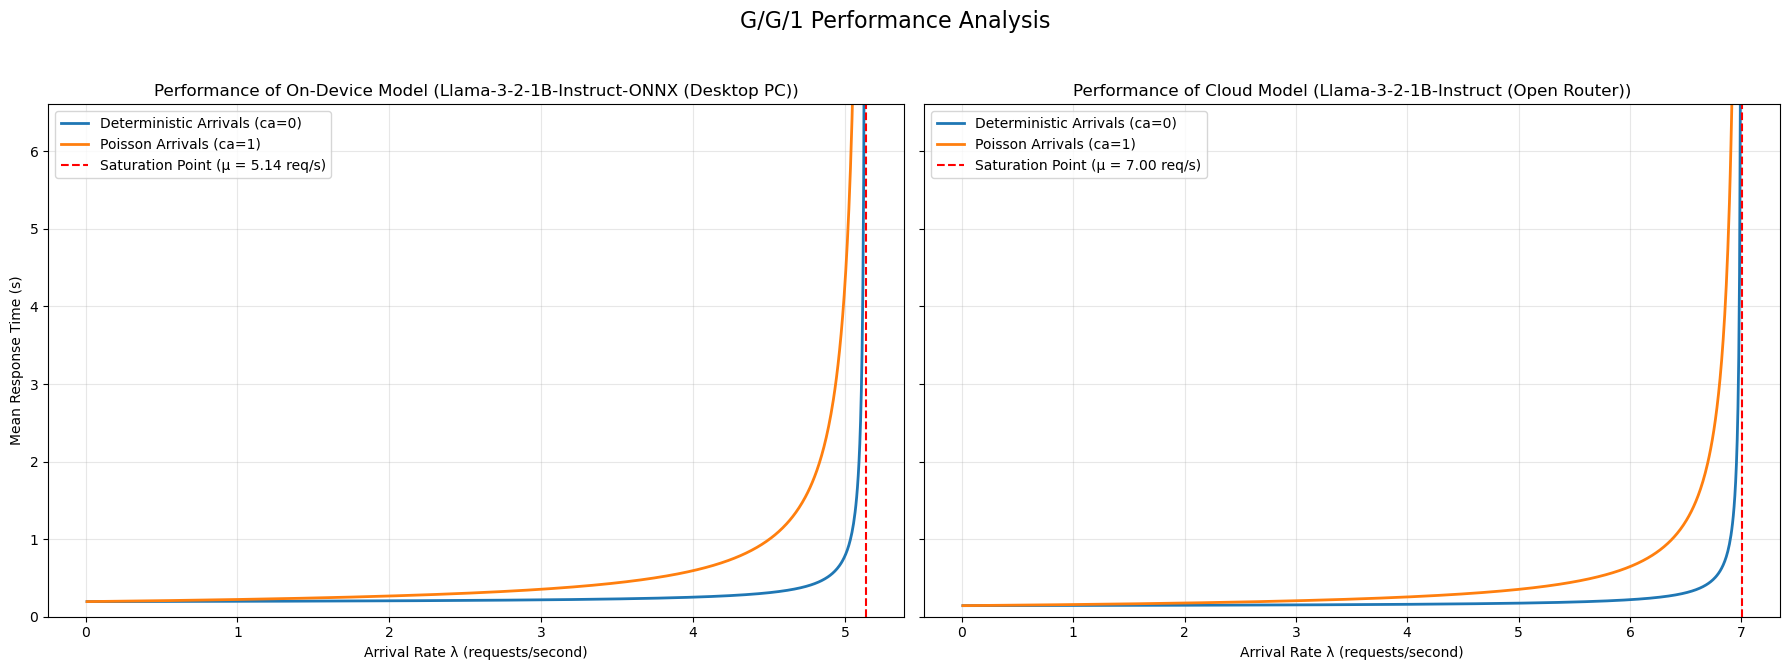

In [36]:
from utils import *
systems_to_analyze = [
    ("On-Device Model (" + name_device + ")", df_device_ex),
    ("Cloud Model (" + name_cloud + ")", df_cloud_ex)
]
mus = plot_system_performance(systems_to_analyze)

## Remarks on Queueing Analysis
We have successfully created a model where we can specify the relationship between input size and inference time for two G/G/1 systems. This allows us to simulate and optimize the system under various theoretical workloads (deterministic or poisson arrival) and hardware configurations, and to test different routing policies